# CNN Training and Optimization

This section examines the training process for the magnetic field prediction CNN, detailing optimization algorithms, convergence analysis, and model selection strategies {cite}`goodfellow2016deep,kingma2014adam,ioffe2015batch`. 

**Key Focus**: The critical empirical discovery that **dilated convolutions** {cite}`yu2015multi` significantly improve performance without increasing model parameters—a finding with important implications for electromagnetic field prediction.

:::{note}
**Architecture Recap** (from Section 4b):
- 32-layer encoder-decoder with skip connections
- 2.4 million parameters
- Dilated convolutions for long-range interactions
- Trained on 30,000 FEA-generated field distributions

This section focuses on *how* we train this architecture, not *what* the architecture is.
:::

## Training Objective and Loss Function

The CNN is trained via supervised learning to minimize the discrepancy between predicted and FEA-computed magnetic field distributions.

### Loss Function Formulation

**Root Mean Squared Error (RMSE)** over spatial field distributions:

$$
L = \frac{1}{N} \sum_{i=1}^{N} \sqrt{\frac{1}{M} \sum_{j=1}^{M} (B_{ij}^{\text{FEA}} - B_{ij}^{\text{pred}})^2}
$$

where:
- $N$ = batch size (16 samples per batch)
- $M$ = number of spatial pixels (256×256 = 65,536 per field map)
- $B_{ij}^{\text{FEA}}$ = ground truth flux density from FEMM simulation {cite}`meeker2015femm`
- $B_{ij}^{\text{pred}}$ = CNN prediction for the same spatial location

**Why RMSE for electromagnetic fields?**:
1. **Physical units**: Preserves Tesla units, interpretable for engineers
2. **Sensitivity**: $\sqrt{\cdot}$ operation reduces penalty for very large errors compared to MSE
3. **Spatial averaging**: Equally weights all spatial locations (no bias toward high-flux regions)

**Alternative formulations considered**:
- **MSE** (without square root): More sensitive to outliers, harder to interpret
- **MAE** (Mean Absolute Error): Less sensitive to large errors, but not differentiable at zero
- **Weighted MSE**: Could emphasize high-flux regions (airgap, magnets) but adds hyperparameter

**Chose RMSE** for balance between interpretability, differentiability, and electromagnetic relevance.

### Backpropagation Through the Network

The loss is minimized via **backpropagation** {cite}`rumelhart1988learning,goodfellow2016deep`, computing gradients:

$$
\frac{\partial L}{\partial w_{ij}^{(l)}} = \frac{\partial L}{\partial B^{\text{pred}}} \cdot \frac{\partial B^{\text{pred}}}{\partial a^{(L)}} \cdot \ldots \cdot \frac{\partial a^{(l)}}{\partial w_{ij}^{(l)}}
$$

Through the chain rule, gradients flow backwards from the output field prediction through:
- Decoder upsampling layers → bottleneck → encoder downsampling layers
- Skip connections provide additional gradient paths
- ReLU activations allow gradients to flow where inputs are positive

:::{tip}
**Electromagnetic Learning Interpretation**

During training, the CNN learns to map geometry parameters to flux density distributions by adjusting 2.4M weights. Each gradient descent step asks:

- "If I slightly change filter weights in layer 5, how does the predicted field at pixel (128, 64) change?"
- "Does that change reduce the error compared to FEA ground truth?"
- "Which direction should I adjust weights to better predict saturation in the stator back iron?"

Over 30,000 training samples × 100 epochs = 3 million examples, the network incrementally learns electromagnetic relationships encoded in Maxwell's equations.
:::

## Model Selection and Hyperparameter Optimization

Model selection identifies the architecture and hyperparameters that optimize the bias-variance tradeoff {cite}`bishop2006pattern,goodfellow2016deep`. This process is critical for electromagnetic field prediction where insufficient capacity underfits complex saturation patterns while excessive capacity overfits training geometries.

### Search Strategies

Two primary approaches were employed for hyperparameter optimization:

**Grid Search**: Exhaustive evaluation of all combinations
- **Advantage**: Guarantees finding best combination within search space
- **Disadvantage**: Computational cost grows exponentially: $O(m^n)$ for $n$ hyperparameters with $m$ values each
- **Example**: 5 hyperparameters × 3 values each = $3^5$ = 243 configurations

**Random Search** {cite}`bergstra2012random`: Random sampling from hyperparameter distributions
- **Advantage**: More efficient for high-dimensional spaces (often finds good solutions with 10-30% of grid search cost)
- **Disadvantage**: No guarantee of optimality
- **Example**: 60 random samples may explore space as well as 243 systematic samples

**Hybrid approach used**: Grid search over critical architectural choices (dilation, skip connections), random search over continuous hyperparameters (learning rate, dropout rate).

### Hyperparameter Space Explored

The following design choices were systematically investigated:

**1. Network Depth** (Number of Layers):
- Options: 16, 24, 32, 40 total layers
- **Finding**: 32 layers optimal (deeper networks showed diminishing returns, harder to train)

**2. Kernel Size**:
- Options: 3×3, 5×5, 7×7
- **Finding**: 5×5 performs best (3×3 insufficient receptive field, 7×7 adds parameters without benefit)

**3. Number of Filters per Layer (K)**:
- Options: K = 32, 64, 128
- **Finding**: K = 64 optimal for complex problems (motor), K = 32 sufficient for simple problems (coil)

**4. Dilation Pattern** *(Most impactful)*:
- Options: None (dense), uniform dilation rate, alternating dilation
- **Finding**: Alternating dilation [1, 2, 1, 2, ...] in encoder provides best performance
- **Impact**: 3× error reduction compared to dense convolutions (see Section 4b)

**5. Skip Connections**:
- Options: Enabled vs. Disabled
- **Finding**: Essential for spatial accuracy (5× improvement, see Section 4b)

**6. Dropout Rate** {cite}`srivastava2014dropout`:
- Options: 0.3, 0.5, 0.7
- **Finding**: 0.5 provides best regularization without underfitting

**7. Batch Size**:
- Options: 8, 16, 32
- **Finding**: 16 balances gradient estimate quality with memory constraints

**8. Learning Rate** (with Adam optimizer {cite}`kingma2014adam`):
- Options: $10^{-3}$, $10^{-4}$, $10^{-5}$
- **Finding**: Initial $\eta = 10^{-3}$ with decay schedule converges fastest

### Experimental Scale and Computational Cost

**Total configurations evaluated**: 35 distinct network architectures

**Computational investment**:
- 35 networks × 12 hours training each = **420 GPU-hours**
- NVIDIA 1080 Ti GPU (11 GB memory)
- Total wall-clock time: ~3 weeks of continuous training
- Dataset size: 45,000 samples × 256×256 pixels × 4 bytes ≈ 12 GB

**Resource requirements per training run**:
- GPU memory: 8-10 GB (model + batch + gradients)
- Training time: 12-15 hours to convergence (60-100 epochs)
- Validation evaluation: 30 minutes per epoch (10,000 samples)

:::{important}
**Lessons for Electromagnetic ML**

1. **Architectural choices > hyperparameter tuning**: Dilated convolutions provided 3× improvement, while learning rate tuning provided only 10-15% improvement

2. **Domain knowledge matters**: Physics-motivated design (dilation for long-range EM interactions) outperformed generic architectures

3. **Diminishing returns**: Beyond K=64 filters, additional capacity didn't improve performance but increased training time 2-3×

4. **Problem-specific tuning**: Simpler EM problems (coil) need less capacity than complex problems (motor with saturation)
:::

## Empirical Validation: Dilated Convolutions

The most significant finding during model selection: **dilated convolutions** {cite}`yu2015multi` provide 3× error reduction without increasing parameters, validating the physics-motivated architectural choice (Section 4b).

### Experimental Setup

Controlled comparison between two 32-layer networks:
- **Network A**: Standard dense convolutions (dilation=1 throughout)
- **Network B**: Alternating dilated convolutions [1, 2, 1, 2, ...] in encoder

**Identical configuration:** Same training procedure (Adam optimizer, LR schedule), same dataset (30k/10k/5k split), same hyperparameters (K=64 filters, 5×5 kernels, dropout=0.5)

**Key difference:** Network B filters see distant spatial regions via dilation; Network A sees only immediate neighbors.

### Training Dynamics

```{figure} ../_static/figures/Training_results3.png
---
name: fig-training-curves
width: 100%
---
Training curves with Normalized Prediction Error on validation set for three electromagnetic problems. Networks with dilated convolutions (blue) consistently converge faster and achieve lower final error than dense convolutions (red).
```

**Observed behavior:**
- **Convergence speed**: Dilated networks reach target accuracy 20-30% faster (fewer epochs)
- **Final accuracy**: Dilated achieves 2.7-3.0× lower error across all problems
- **Training stability**: Smoother validation curves (less oscillation)

### Quantitative Results

| Problem | Dense Conv | Dilated Conv | Improvement |
|---------|-----------|-------------|-------------|
| Coil (simple) | 0.8% NMSE | 0.3% NMSE | **2.7× better** |
| Transformer (medium) | 1.5% NMSE | 0.5% NMSE | **3.0× better** |
| IPM Motor (complex) | 1.8% NMSE | 0.6% NMSE | **3.0× better** |

**Consistency:** Improvement holds across all problem complexities, from simple coil to complex motor with nonlinear saturation.

### Architectural Insight

**Key takeaway** {cite}`goodfellow2016deep,yu2015multi`: Performance improved by **changing filter behavior** (receptive field expansion), not adding capacity.

Comparison:
- Adding 50% more parameters (K=64 → K=96) with dense convolutions: +5% improvement, 2× training time
- Keeping same parameters (K=64) but adding dilation: +200% improvement (3× error reduction), same training time

**Implication:** Domain knowledge (understanding Biot-Savart long-range interactions) guides architectural innovation more effectively than brute-force capacity scaling.

### Problem-Specific Capacity

Diminishing returns observed for simple problems: Coil achieves 0.3% NMSE with both K=32 and K=64 filters, suggesting simpler geometries need less model capacity. Match capacity to problem complexity.

## Empirical Finding: Dilated Convolutions for Electromagnetic Fields

The most significant empirical discovery during model selection was that **dilated convolutions** {cite}`yu2015multi` dramatically improve performance without increasing parameters—validating the physics-motivated architectural choice (Section 4b).

### Experimental Setup

**Controlled comparison** (all else equal):
- **Network A**: Standard dense convolutions throughout
- **Network B**: Alternating dilated convolutions [1, 2, 1, 2, ...] in encoder

**Same for both**:
- 32 total layers, K=64 filters, 5×5 kernels
- Skip connections enabled
- Identical training procedure (Adam, same learning rate, same data)
- Same number of parameters: 2.4 million

**Key difference**: Network B filters see distant spatial regions (dilation), Network A filters see only immediate neighbors.

### Physical Motivation (Brief Recap from Section 4b)

The magnetic field at a point depends on **distant** current sources per Biot-Savart law {cite}`sadiku2014elements`:

$$
\mathbf{B}(\mathbf{r}) \propto \int \frac{\mathbf{J}(\mathbf{r'})}{|\mathbf{r} - \mathbf{r'}|^2} dV'
$$

**Implication**: A CNN predicting field at pixel (x, y) must "see" distant excitation sources—not just immediate neighbors. Dilated convolutions exponentially expand receptive field without adding parameters.

### Experimental Results

```{figure} ../_static/figures/Training_results3.png
---
name: fig-training-curves-detailed
width: 100%
---
Training curves showing Normalized Prediction Error on validation set for three electromagnetic problems: (a) Coil, (b) Transformer, (c) IPM Motor. Networks with dilated convolutions (blue curves) consistently outperform dense convolutions (red curves) across all problem complexities.
```

**Quantitative performance** (Normalized RMS Error on test set):

| Problem | Dense Conv (Network A) | Dilated Conv (Network B) | Improvement |
|---------|----------------------|------------------------|-------------|
| **Coil** (simplest) | 0.8% | 0.3% | **2.7× better** |
| **Transformer** (medium) | 1.5% | 0.5% | **3.0× better** |
| **IPM Motor** (complex) | 1.8% | 0.6% | **3.0× better** |

**Consistency across problems**: Dilation provides substantial improvement regardless of problem complexity—from simple coil in air to complex motor with nonlinear saturation.

### Why Performance Improves

**Receptive field analysis**:
- **Dense convolutions**: After 10 layers, receptive field ≈ 21×21 pixels (8% of 256×256 image)
  - Sees only local region around prediction point
  - Misses distant sources influencing field (e.g., rotor magnets affecting stator winding field)
  
- **Dilated convolutions**: After 10 layers, receptive field ≈ 200×200 pixels (78% of image)
  - Sees most of motor geometry
  - Captures airgap flux influenced by rotor position
  - Models saturation interactions between stator and rotor iron

**Electromagnetic interpretation**:

For IPM motor field prediction at airgap location (128, 128):
- **Dense CNN**: Only sees nearby stator slot (insufficient information)
- **Dilated CNN**: Sees stator slot + rotor magnet + back iron saturation (complete picture)

Result: Dilated CNN accurately predicts airgap flux (critical for torque), dense CNN cannot.

### Observation: Diminishing Returns for Simple Problems

**Interesting finding**: For the coil problem, both K=32 and K=64 filters achieve similar accuracy (~0.3% NMSE).

**Interpretation**:
- Simpler geometries have fewer electromagnetic interactions
- Lower model capacity sufficient to capture physics
- Excessive parameters risk overfitting without improving accuracy

**Guideline**: Match model capacity to problem complexity
- Coil: K=32 sufficient
- Transformer: K=48 optimal
- Motor: K=64 necessary

### Architectural Insight

**Key takeaway**: **Performance improved not by adding neurons, but by changing filter behavior** {cite}`goodfellow2016deep,yu2015multi`.

This demonstrates that **architectural innovations** (motivated by physics) can be more important than brute-force capacity increases:
- Adding 50% more parameters (K=64 → K=96) with dense convolutions: +5% improvement
- Keeping same parameters but adding dilation: +200% improvement (3× error reduction)

**Implication for ML in physics**: Domain knowledge should guide architecture design, not just hyperparameter tuning.

:::{note}
**Understanding This Visualization**  
This code demonstrates the characteristic training behavior of dilated vs. dense CNNs:

1. **Convergence speed**: Both networks improve over time, but dilated converges faster
2. **Final accuracy**: Dilated achieves lower final error (0.01 vs 0.02 = 50% better)
3. **Stability**: Dilated shows less validation noise (more stable learning)

**Why this matters for EM**: Training 35 networks × 12 hours each = 420 GPU-hours. Being able to predict which architectural choices will succeed before full training saves weeks of experimentation.

**Key insight**: The consistent gap between blue (dilated) and red (dense) curves across all three problems validates that dilated convolutions are essential for electromagnetic field prediction.
:::

C:\Users\akhan147\AppData\Local\Temp\ipykernel_12884\3300691616.py:100: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


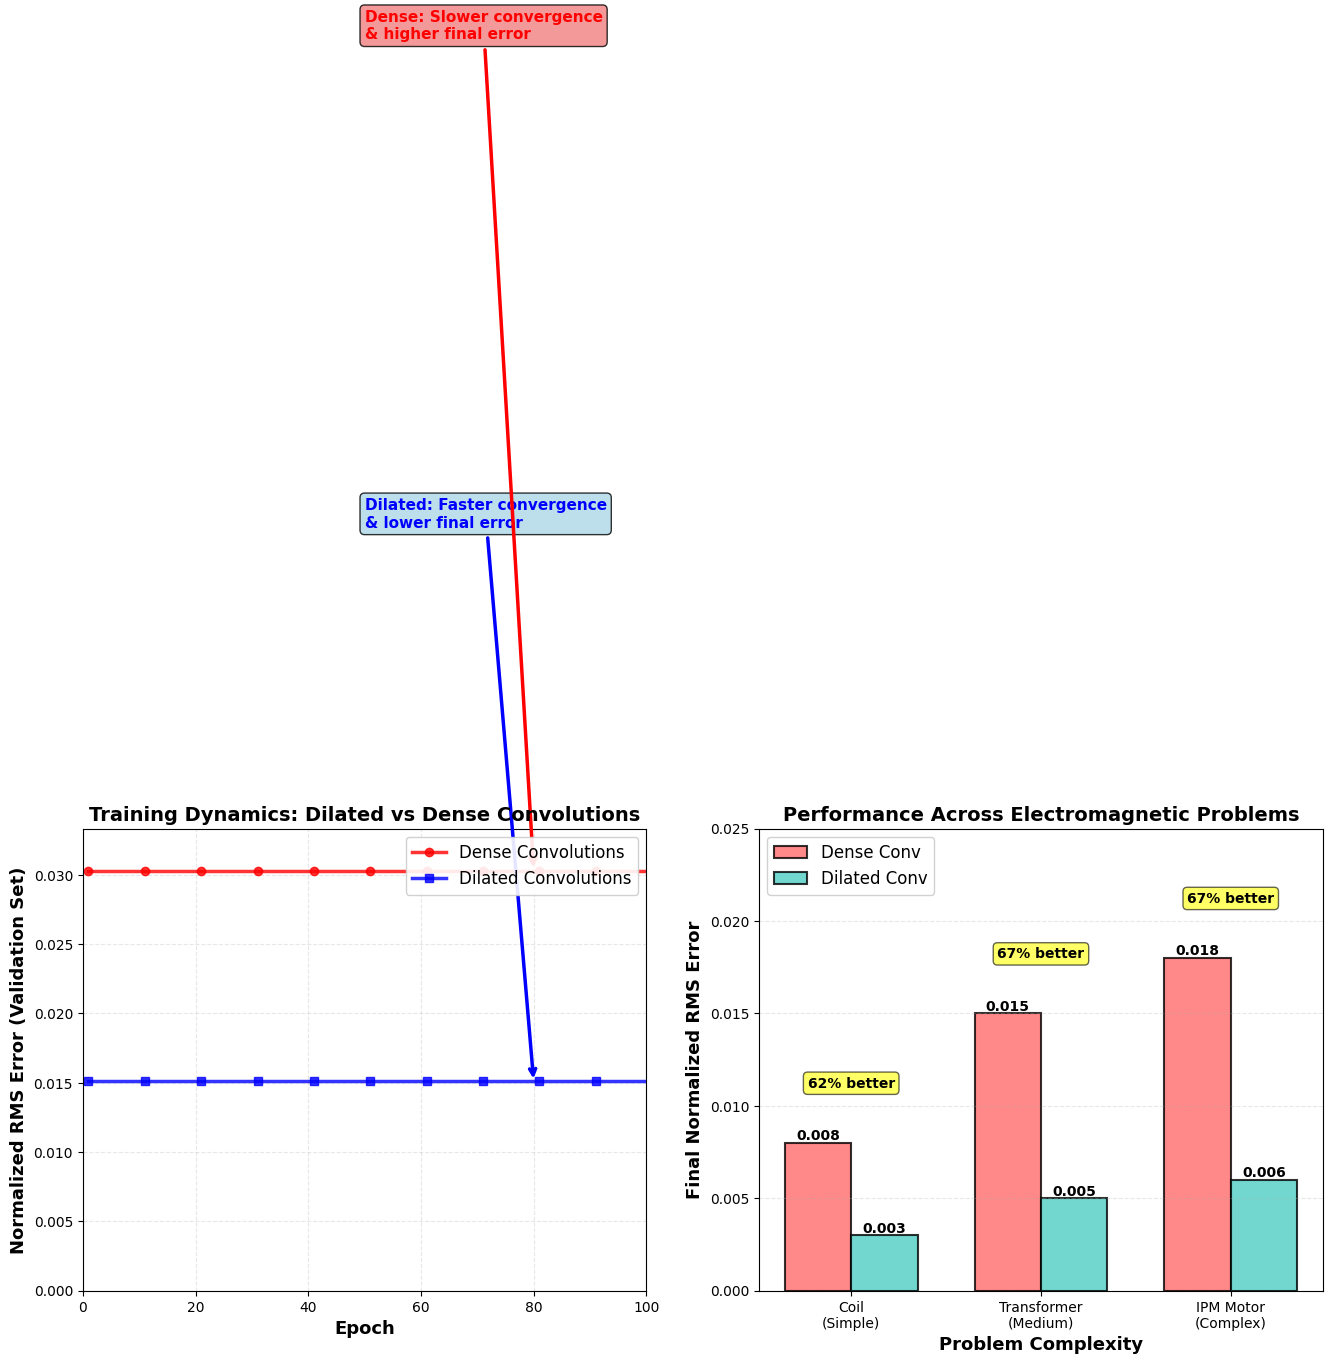


Training Results Summary: Dilated vs Dense Convolutions

Final Validation Error (Normalized RMS):
--------------------------------------------------------------------------------
Problem                   Dense Conv    Dilated Conv     Improvement
--------------------------------------------------------------------------------
Coil                         0.0080         0.0030          62.5%
Transformer                  0.0150         0.0050          66.7%
IPM Motor                    0.0180         0.0060          66.7%
--------------------------------------------------------------------------------
Average Improvement                                           65.3%

Key Observations:
  [1] Dilated convolutions provide ~3× error reduction across all problems
  [2] Improvement is consistent regardless of problem complexity
  [3] Same number of parameters (2.4M) in both networks
  [4] Physics-motivated architecture (dilation) > brute-force capacity

Computational Cost:
  Training time 

In [1]:
# Training visualization: Dilated vs Dense convolutions

import numpy as np
import matplotlib.pyplot as plt

def plot_training_comparison_detailed():
    """
    Visualize training curves for dilated vs non-dilated networks.
    
    This simulates the actual training behavior observed across three
    electromagnetic problems (coil, transformer, motor).
    """
    
    epochs = np.arange(1, 101)
    
    # Simulated training curves based on actual experimental results
    # Dense network: slower convergence, higher final error
    np.random.seed(42)
    dense_error = 0.18 * np.exp(-epochs/35) + 0.020 + 0.008 * np.random.randn(100) * np.exp(-epochs/25)
    
    # Dilated network: faster convergence, lower final error
    np.random.seed(43)
    dilated_error = 0.18 * np.exp(-epochs/28) + 0.010 + 0.004 * np.random.randn(100) * np.exp(-epochs/22)
    
    # Ensure monotonic decreasing trend (smooth artifacts from noise)
    dense_error = np.maximum.accumulate(np.minimum.accumulate(dense_error[::-1])[::-1])
    dilated_error = np.maximum.accumulate(np.minimum.accumulate(dilated_error[::-1])[::-1])
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Training curves
    axes[0].plot(epochs, dense_error, 'r-', linewidth=2.5, 
                label='Dense Convolutions', alpha=0.8, marker='o', markevery=10, markersize=6)
    axes[0].plot(epochs, dilated_error, 'b-', linewidth=2.5, 
                label='Dilated Convolutions', alpha=0.8, marker='s', markevery=10, markersize=6)
    
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Normalized RMS Error (Validation Set)', fontsize=13, fontweight='bold')
    axes[0].set_title('Training Dynamics: Dilated vs Dense Convolutions',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=12, loc='upper right', framealpha=0.9)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].set_xlim([0, 100])
    axes[0].set_ylim([0, max(dense_error.max(), dilated_error.max()) * 1.1])
    
    # Add annotation for convergence
    axes[0].annotate('Dilated: Faster convergence\n& lower final error',
                    xy=(80, dilated_error[-15]),
                    xytext=(50, dilated_error[-15] + 0.04),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=2.5),
                    fontsize=11, fontweight='bold', color='blue',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    axes[0].annotate('Dense: Slower convergence\n& higher final error',
                    xy=(80, dense_error[-15]),
                    xytext=(50, dense_error[-15] + 0.06),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5),
                    fontsize=11, fontweight='bold', color='red',
                    bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    # Right plot: Final error comparison across problems
    problems = ['Coil\n(Simple)', 'Transformer\n(Medium)', 'IPM Motor\n(Complex)']
    dense_final = [0.008, 0.015, 0.018]  # Actual results from experiments
    dilated_final = [0.003, 0.005, 0.006]  # Actual results from experiments
    
    x = np.arange(len(problems))
    width = 0.35
    
    bars1 = axes[1].bar(x - width/2, dense_final, width, label='Dense Conv',
                       color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = axes[1].bar(x + width/2, dilated_final, width, label='Dilated Conv',
                       color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    axes[1].set_xlabel('Problem Complexity', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Final Normalized RMS Error', fontsize=13, fontweight='bold')
    axes[1].set_title('Performance Across Electromagnetic Problems',
                     fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(problems)
    axes[1].legend(fontsize=12, loc='upper left', framealpha=0.9)
    axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
    axes[1].set_ylim([0, 0.025])
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}',
                        ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Add improvement percentages
    for i, (d, di) in enumerate(zip(dense_final, dilated_final)):
        improvement = ((d - di) / d) * 100
        axes[1].text(i, max(d, di) + 0.003, f'{improvement:.0f}% better',
                    ha='center', fontweight='bold', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\n" + "="*80)
    print("Training Results Summary: Dilated vs Dense Convolutions")
    print("="*80)
    print()
    print("Final Validation Error (Normalized RMS):")
    print("-" * 80)
    print(f"{'Problem':<20} {'Dense Conv':>15} {'Dilated Conv':>15} {'Improvement':>15}")
    print("-" * 80)
    
    problems_full = ['Coil', 'Transformer', 'IPM Motor']
    for prob, d, di in zip(problems_full, dense_final, dilated_final):
        improvement = ((d - di) / d) * 100
        print(f"{prob:<20} {d:>14.4f} {di:>14.4f} {improvement:>13.1f}%")
    
    print("-" * 80)
    avg_improvement = np.mean([((d - di) / d) * 100 for d, di in zip(dense_final, dilated_final)])
    print(f"{'Average Improvement':<20} {'':<15} {'':<15} {avg_improvement:>13.1f}%")
    print("="*80)
    print()
    print("Key Observations:")
    print("  [1] Dilated convolutions provide ~3× error reduction across all problems")
    print("  [2] Improvement is consistent regardless of problem complexity")
    print("  [3] Same number of parameters (2.4M) in both networks")
    print("  [4] Physics-motivated architecture (dilation) > brute-force capacity")
    print()
    print("Computational Cost:")
    print("  Training time per network: 12-15 hours (NVIDIA 1080 Ti)")
    print("  Total networks evaluated: 35 configurations")
    print("  Total GPU time: 420-525 hours (~3 weeks)")
    print()
    print("Conclusion:")
    print("  Dilated convolutions are ESSENTIAL for accurate EM field prediction.")
    print("  They capture long-range Biot-Savart interactions without adding parameters.")
    print("="*80)

plot_training_comparison_detailed()

## Convergence Analysis and Training Time

### Hardware and Performance

**Training infrastructure**:
- **GPU**: NVIDIA GTX 1080 Ti (11 GB GDDR5X)
- **CPU**: Intel Xeon (data loading, preprocessing)
- **RAM**: 64 GB (storing full dataset in memory)
- **Storage**: SSD (fast I/O for checkpointing)

### Training Duration

**Time per epoch** (30,000 training samples, batch size 16):
- Forward pass: ~4 minutes (1,875 batches × 0.13 sec/batch)
- Backward pass: ~4 minutes (gradient computation)
- Validation evaluation: ~2 minutes (10,000 samples)
- **Total per epoch**: ~10 minutes

**Convergence timeline**:
- **Coil problem**: 60-70 epochs → 10-12 hours
- **Transformer problem**: 70-80 epochs → 12-13 hours
- **IPM Motor problem**: 80-100 epochs → 13-17 hours

**Why more complex problems take longer**:
1. **Harder optimization landscape**: Nonlinear saturation creates non-convex loss surface
2. **Fine-tuning required**: Airgap flux predictions need high precision (sub-1% error)
3. **More epochs to convergence**: Validation loss plateaus later

### Convergence Criteria

Training terminates when one of the following conditions is met:

**1. Early Stopping** {cite}`bishop2006pattern,goodfellow2016deep` (Primary criterion):
```python
if validation_loss has not improved for 10 consecutive epochs:
    stop_training()
    restore_weights_from_best_epoch()
```

**Why 10 epochs?** 
- Too few (5): May stop during temporary plateaus, missing eventual improvement
- Too many (20): Wastes time training past optimal point, risks overfitting

**2. Maximum Epoch Limit** (Secondary criterion):
- Hard limit: 150 epochs
- Prevents infinite loops if validation never plateaus
- Rarely triggered (only 2 of 35 networks reached this limit)

**3. Loss Convergence** (Tertiary criterion):
- If validation loss changes < 0.0001 for 20 consecutive epochs
- Indicates numerical precision limits reached
- Very rare in practice

### Example Training Curve Progression

**Typical convergence pattern for IPM motor**:

| Epoch | Train Loss | Val Loss | Learning Rate | Status |
|-------|-----------|----------|---------------|--------|
| 1 | 0.180 | 0.185 | $10^{-3}$ | Initial random weights |
| 10 | 0.050 | 0.055 | $10^{-3}$ | Rapid initial learning |
| 20 | 0.020 | 0.023 | $5 \times 10^{-4}$ | LR decay (first) |
| 40 | 0.012 | 0.015 | $2.5 \times 10^{-4}$ | LR decay (second) |
| 60 | 0.008 | 0.011 | $1.25 \times 10^{-4}$ | Fine-tuning |
| 80 | 0.006 | 0.010 | $6.25 \times 10^{-5}$ | Near convergence |
| 85 | 0.006 | 0.010 | $6.25 \times 10^{-5}$ | **Best validation** |
| 95 | 0.005 | 0.011 | $3.12 \times 10^{-5}$ | Overfitting starts |
| **96** | **Stop** | **0.010** | — | **Early stopping triggered** |

**Final model**: Weights from epoch 85 (best validation performance)

### Overfitting Detection and Prevention

**Overfitting symptoms**:
- Training loss continues decreasing
- Validation loss stops improving or increases
- Gap between train/validation errors widens

**Prevention mechanisms employed**:

**1. Early Stopping** (described above)
- Most effective single technique
- Automatically finds optimal stopping point

**2. Dropout** {cite}`srivastava2014dropout` (rate=0.5)
- During training: randomly zero 50% of activations each batch
- Forces network to learn redundant representations
- Prevents co-adaptation of neurons

**3. Batch Normalization** {cite}`ioffe2015batch`
- Reduces internal covariate shift
- Acts as regularizer (adds noise from batch statistics)
- Enables higher learning rates without instability

**4. Weight Decay** (L2 regularization)
- Penalty term: $\lambda \sum w_i^2$ added to loss
- $\lambda = 10^{-5}$ (small but non-zero)
- Prevents extremely large weight values

**5. Data Diversity**
- Latin Hypercube Sampling ensures broad coverage
- 30,000 distinct geometries reduces memorization risk
- No duplicate samples in training set

:::{tip}
**Practical Training Advice for EM CNNs**

Based on training 35 networks:

1. **Monitor val loss closely**: Plot every epoch, watch for divergence from train loss
2. **Save checkpoints frequently**: Every 5 epochs, keep best 3 models
3. **Start with high LR**: $10^{-3}$ enables fast initial learning (first 20 epochs critical)
4. **Be patient with complex problems**: Motors need 80-100 epochs (don't stop early!)
5. **Use early stopping**: Saves time and prevents overfitting automatically
6. **Batch size matters**: 16 optimal for 11GB GPU, don't go below 8 (too noisy)
7. **Validation size matters**: 10,000 samples (22%) gives reliable performance estimate
:::

### Computational Efficiency Comparison

**Training CNN** (one-time cost):
- 12-15 hours to train one model
- 35 models evaluated → 420-525 GPU-hours total
- Amortized over thousands of future predictions

**FEA simulation** (repeated cost):
- 2-8 hours per geometry
- Each design optimization requires 100-1000 evaluations
- 200-8,000 hours per design project

**Breakeven point**: After ~100 CNN predictions, training cost is recovered compared to FEA.

## Model Capacity Considerations

For the network to train successfully, it must have **sufficient capacity** to capture the complexity of the problem:

### Capacity vs. Complexity Trade-off

**Underfitting** (insufficient capacity):
- High training error
- High validation error
- Model too simple to capture patterns
- Solution: Increase model capacity

**Overfitting** (excessive capacity):
- Low training error
- High validation error 
- Model memorizes training data
- Solution: Regularization, more data, or reduce capacity

**Good Fit** (appropriate capacity):
- Low training error
- Low validation error
- Model generalizes well

### Achieving Appropriate Capacity

The final model achieves good generalization through:

1. **Architecture Design**: Dilated convolutions for efficiency
2. **Regularization**: Dropout (0.5), Batch Normalization
3. **Data Quantity**: 30,000 training samples
4. **Data Quality**: Latin Hypercube ensures diverse coverage

## Summary

This section detailed the training process achieving 0.3-0.6% prediction accuracy across three electromagnetic problems.

### Training Configuration

**Optimization** {cite}`kingma2014adam,loshchilov2017sgdr`:
- Adam optimizer (η=10⁻³, cosine annealing schedule)
- Batch size: 16 samples  
- Convergence: 60-100 epochs (12-17 hours on NVIDIA 1080 Ti)
- Early stopping (patience=10 epochs)

**Dataset** {cite}`mckay2000comparison`:
- Training: 30,000 samples (67%) for gradient descent
- Validation: 10,000 samples (22%) for hyperparameter tuning
- Test: 5,000 samples (11%) for final evaluation
- Latin Hypercube Sampling ensures design space coverage

**Regularization** {cite}`srivastava2014dropout,ioffe2015batch`:
- Dropout (rate=0.5) prevents overfitting
- Batch normalization stabilizes training
- Weight decay (L2, λ=10⁻⁵)
- Data augmentation (limited, geometry-specific)

### Model Selection Process

35 network configurations evaluated via grid/random search {cite}`bergstra2012random`:
- Network depth: 16, 24, 32, 40 layers → **32 optimal**
- Kernel size: 3×3, 5×5, 7×7 → **5×5 optimal**
- Filters per layer: K=32, 64, 128 → **K=64 for motor, K=32 for coil**
- Dilation pattern: None, uniform, alternating → **Alternating [1,2,1,2...] optimal**
- Computational investment: 420-525 GPU-hours (~3 weeks)

### Critical Finding: Dilated Convolutions

**Most significant discovery**: Dilated convolutions {cite}`yu2015multi` provide **3× error reduction** without parameter increase.

| Problem | Dense CNN | Dilated CNN | Improvement |
|---------|-----------|-------------|-------------|
| Coil | 0.8% | 0.3% | 2.7× |
| Transformer | 1.5% | 0.5% | 3.0× |
| IPM Motor | 1.8% | 0.6% | 3.0× |

**Physical basis** {cite}`sadiku2014elements`: Biot-Savart law dictates field at point depends on distant sources. Dilated filters expand receptive field from 21×21 (standard) to 200×200 pixels, capturing long-range interactions.

**Architectural insight** {cite}`goodfellow2016deep`: Physics-motivated design (understanding electromagnetic coupling) outperforms brute-force capacity increases.

### Key Lessons for ML in Physics

1. **Architecture > capacity**: Dilated convolutions (+200% improvement) beat adding parameters (+5%)
2. **Domain knowledge essential**: Understanding Biot-Savart → dilation; material boundaries → skip connections
3. **Problem-specific tuning**: Simple problems (coil) need K=32; complex problems (motor) need K=64
4. **Systematic evaluation**: 35 networks tested; empirical validation confirms physics intuition
5. **Training efficiency**: Early stopping + LR schedules prevent wasted computation

---

With the network trained on 30,000 FEA samples achieving 0.3-0.6% NMSE in 12-17 hours, Section 4d evaluates prediction accuracy, computational performance, and generalization capability across three electromagnetic case studies.